# Stance Detection — Train + Comparative Analysis

This notebook trains and compares the Twitter-RoBERTa model and the regular RoBERTa model on the PHEME/RumourEval stance dataset. It uses leave-one-event-out evaluation so each event gets tested as the held-out event.

In [ ]:
!nvidia-smi

Fri May  1 21:42:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1 — Setup

In [ ]:
import os, sys

REPO_URL  = "https://github.com/davisclrk/RoBERTa-stance-analysis"
REPO_NAME = "RoBERTa-stance-analysis"
REPO_PATH = f"/content/{REPO_NAME}"

if not os.path.isdir(REPO_PATH):
    !git clone {REPO_URL} {REPO_PATH}
else:
    print("Repo already cloned — pulling latest.")
    !git -C {REPO_PATH} pull

%cd {REPO_PATH}
sys.path.insert(0, "src")

!pip install -q -r requirements.txt
!pip install -q captum umap-learn

Repo already cloned — pulling latest.
Already up to date.
/content/RoBERTa-stance-analysis


## 2 — Download & extract PHEME dataset

Sets up the repo in Colab and installs/imports the files needed to run the training and analysis code.

In [ ]:
from pathlib import Path
from google.colab import files

data_dir = Path("data/raw")
data_dir.mkdir(parents=True, exist_ok=True)

!bash scripts/extract_data.sh

"""
if not (data_dir / "phemerumourschemedataset").exists():
    print("Upload phemerumourschemedataset.tar.bz2")
    files.upload()
    !bash scripts/extract_data.sh
else:
    print("PHEME dataset already available.")"""

Extracting...
Done. Dataset available at data/raw/pheme-rumour-scheme-dataset


'\nif not (data_dir / "phemerumourschemedataset").exists():\n    print("Upload phemerumourschemedataset.tar.bz2")\n    files.upload()\n    !bash scripts/extract_data.sh\nelse:\n    print("PHEME dataset already available.")'

## 3 — Check the data pipeline

Loads the dataset, checks the label counts, and makes sure the leave-one-event-out splits are being created correctly.

In [ ]:
import sys
sys.path.insert(0, "src")

from collections import Counter
from data import load_pheme_dataset, loeo_splits

examples = load_pheme_dataset()
label_names = ["support", "deny", "query", "comment"]
counts = Counter(ex["label"] for ex in examples)

print(f"Total examples: {len(examples)}")
print("Label distribution:")
for i, name in enumerate(label_names):
    print(f"  {name:<10} {counts[i]:>4}  ({100*counts[i]/len(examples):.1f}%)")

splits = loeo_splits(examples)
print("\nLOEO folds:")
for event, train, test in splits:
    print(f"  held-out={event:<22}  train={len(train):>4}  test={len(test):>4}")

Total examples: 4263
Label distribution:
  support     645  (15.1%)
  deny        334  (7.8%)
  query       361  (8.5%)
  comment    2923  (68.6%)

LOEO folds:
  held-out=putinmissing            train=4205  test=  58
  held-out=charliehebdo            train=3261  test=1002
  held-out=prince-toronto          train=4172  test=  91
  held-out=ferguson                train=3221  test=1042
  held-out=germanwings-crash       train=4002  test= 261
  held-out=ottawashooting          train=3539  test= 724
  held-out=sydneysiege             train=3210  test=1053
  held-out=ebola-essien            train=4231  test=  32


## 4 — Train twitter-roberta-base

Trains `cardiffnlp/twitter-roberta-base` using leave-one-event-out evaluation. Results and saved outputs are written to the `outputs` folder.

In [ ]:
import importlib
import config
from pathlib import Path

# Ensure config is set to the twitter-roberta run
config.MODEL_NAME = "cardiffnlp/twitter-roberta-base"
config.OUTPUTS    = Path("outputs")

import train as _train_mod
importlib.reload(_train_mod)
from train import run_loeo

print("Starting twitter-roberta-base training...")
results_tw = run_loeo()

Starting twitter-roberta-base training...
Device: cuda  |  seeds per fold: 1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  [ebola-essien seed=42] epoch 2  loss=1.174  macro_f1=0.4649  acc=0.4375


  [ebola-essien seed=42] epoch 3  loss=1.049  macro_f1=0.3865  acc=0.4375


  [ebola-essien seed=42] epoch 4  loss=0.974  macro_f1=0.5104  acc=0.5000


  [ebola-essien seed=42] epoch 5  loss=0.903  macro_f1=0.4940  acc=0.4688


  [ebola-essien seed=42] epoch 6  loss=0.847  macro_f1=0.4555  acc=0.4375
  [ebola-essien seed=42] early stop at epoch 6 (best epoch 4, macro_f1=0.5104)
              precision    recall  f1-score   support

     support       0.25      0.75      0.38         4
        deny       0.67      0.33      0.44         6
       query       0.50      1.00      0.67         1
     comment       0.67      0.48      0.56        21

    accuracy                           0.50        32
   macro avg       0.52      0.64      0.51        32
weighted avg       0.61      0.50      0.52        32

  [ebola-essien] across 1 seeds: macro_f1=0.5104±0.0000  acc=0.5000±0.0000

LOEO Summary (mean over 1 seeds; ± shows std across seeds)
Event                      support      deny     query   comment       macro_f1            acc
----------------------------------------------------------------------------------------------
putinmissing                0.2667    0.3636    0.5217    0.7463  0.4746±0.0000  0.6034

## 5 — Train roberta-base ablation

Runs the same training setup with regular `roberta-base` instead of Twitter-RoBERTa. This gives us an ablation to compare against the Twitter-pretrained model.

In [ ]:
import importlib
import config
from pathlib import Path

# Switch config to the ablation model
config.MODEL_NAME = "roberta-base"
config.OUTPUTS    = Path("outputs_roberta_base")

import train as _train_mod
importlib.reload(_train_mod)
from train import run_loeo

print("Starting roberta-base training...")
results_rb = run_loeo(output_dir=config.OUTPUTS)

Starting roberta-base training...
Device: cuda  |  seeds per fold: 1


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  [ebola-essien seed=42] epoch 2  loss=1.167  macro_f1=0.5398  acc=0.5938


  [ebola-essien seed=42] epoch 3  loss=1.056  macro_f1=0.6417  acc=0.5938


  [ebola-essien seed=42] epoch 4  loss=0.982  macro_f1=0.6985  acc=0.6250


  [ebola-essien seed=42] epoch 5  loss=0.929  macro_f1=0.6368  acc=0.6250


  [ebola-essien seed=42] epoch 6  loss=0.861  macro_f1=0.6034  acc=0.4688
  [ebola-essien seed=42] early stop at epoch 6 (best epoch 4, macro_f1=0.6985)
              precision    recall  f1-score   support

     support       0.27      0.75      0.40         4
        deny       0.80      0.67      0.73         6
       query       1.00      1.00      1.00         1
     comment       0.80      0.57      0.67        21

    accuracy                           0.62        32
   macro avg       0.72      0.75      0.70        32
weighted avg       0.74      0.62      0.66        32

  [ebola-essien] across 1 seeds: macro_f1=0.6985±0.0000  acc=0.6250±0.0000

LOEO Summary (mean over 1 seeds; ± shows std across seeds)
Event                      support      deny     query   comment       macro_f1            acc
----------------------------------------------------------------------------------------------
putinmissing                0.1667    0.5714    0.6667    0.8333  0.5595±0.0000  0.7069

## 6 — Load results

Loads the saved result files from both model runs so the rest of the notebook can compare their scores.

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

LABEL_NAMES = ["support", "deny", "query", "comment"]
TW_COLOR    = "#4C72B0"
RB_COLOR    = "#DD8452"
W           = 0.35          # bar width used in all charts

with open("outputs/loeo_results.json") as f:
    tw = json.load(f)
with open("outputs_roberta_base/loeo_results.json") as f:
    rb = json.load(f)

events = list(tw.keys())

# Scalar lists re-used across analysis cells
tw_macro = [tw[e]["macro_f1_mean"] for e in events]
rb_macro = [rb[e]["macro_f1_mean"] for e in events]
tw_acc   = [tw[e]["accuracy_mean"]  for e in events]
rb_acc   = [rb[e]["accuracy_mean"]  for e in events]

# Summary table
rows = []
for e in events:
    rows.append({
        "event":       e,
        "TW macro-F1": f"{tw[e]['macro_f1_mean']:.4f} ± {tw[e]['macro_f1_std']:.4f}",
        "RB macro-F1": f"{rb[e]['macro_f1_mean']:.4f} ± {rb[e]['macro_f1_std']:.4f}",
        "TW accuracy": f"{tw[e]['accuracy_mean']:.4f} ± {tw[e]['accuracy_std']:.4f}",
        "RB accuracy": f"{rb[e]['accuracy_mean']:.4f} ± {rb[e]['accuracy_std']:.4f}",
        "winner":      "TW" if tw[e]["macro_f1_mean"] > rb[e]["macro_f1_mean"] else "RB",
    })
rows.append({
    "event":       "MEAN",
    "TW macro-F1": f"{np.mean(tw_macro):.4f}",
    "RB macro-F1": f"{np.mean(rb_macro):.4f}",
    "TW accuracy": f"{np.mean(tw_acc):.4f}",
    "RB accuracy": f"{np.mean(rb_acc):.4f}",
    "winner":      "TW" if np.mean(tw_macro) > np.mean(rb_macro) else "RB",
})
print(pd.DataFrame(rows).set_index("event").to_string())

                       TW macro-F1      RB macro-F1      TW accuracy      RB accuracy winner
event                                                                                       
putinmissing       0.4746 ± 0.0000  0.5595 ± 0.0000  0.6034 ± 0.0000  0.7069 ± 0.0000     RB
charliehebdo       0.5075 ± 0.0000  0.5034 ± 0.0000  0.7016 ± 0.0000  0.7156 ± 0.0000     TW
prince-toronto     0.4708 ± 0.0000  0.4554 ± 0.0000  0.7033 ± 0.0000  0.7363 ± 0.0000     TW
ferguson           0.4030 ± 0.0000  0.4169 ± 0.0000  0.6152 ± 0.0000  0.6382 ± 0.0000     RB
germanwings-crash  0.5193 ± 0.0000  0.5814 ± 0.0000  0.6628 ± 0.0000  0.7011 ± 0.0000     RB
ottawashooting     0.4488 ± 0.0000  0.4623 ± 0.0000  0.6450 ± 0.0000  0.6547 ± 0.0000     RB
sydneysiege        0.4721 ± 0.0000  0.4867 ± 0.0000  0.6429 ± 0.0000  0.6828 ± 0.0000     RB
ebola-essien       0.5104 ± 0.0000  0.6985 ± 0.0000  0.5000 ± 0.0000  0.6250 ± 0.0000     RB
MEAN                        0.4758           0.5205           0.6343  

## 7 — Macro-F1 and accuracy by event

Plots macro-F1 and accuracy for each held-out event. This helps show which events were easier or harder for each model.

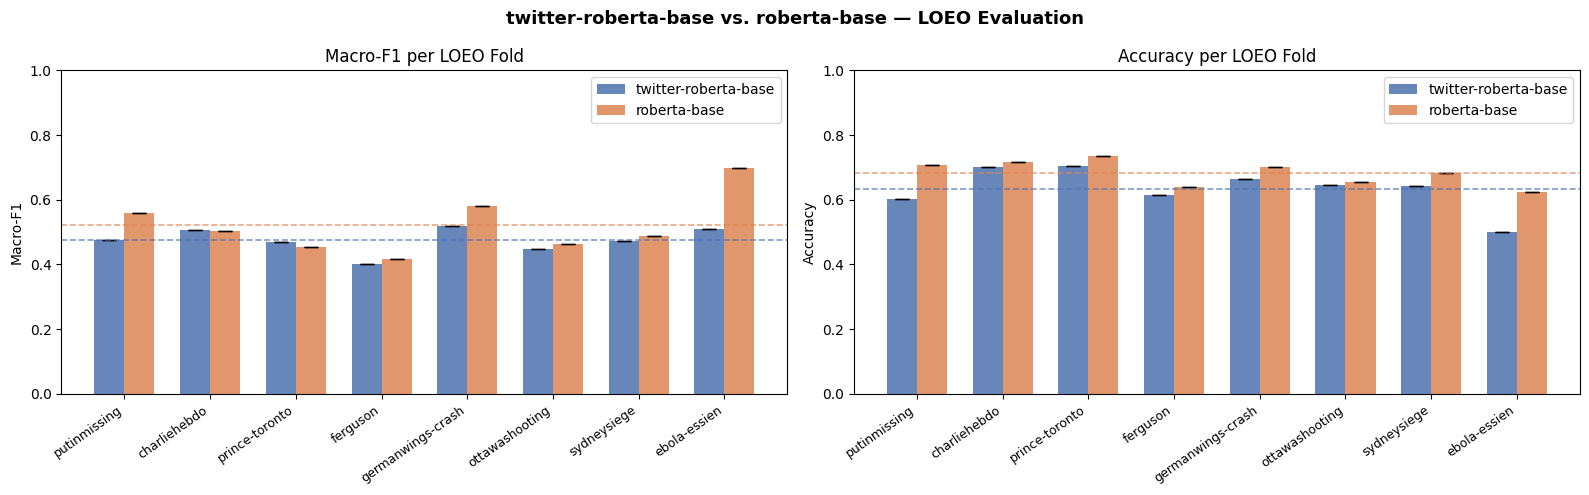

In [ ]:
import matplotlib.pyplot as plt

tw_macro_m = np.array([tw[e]["macro_f1_mean"] for e in events])
tw_macro_s = np.array([tw[e]["macro_f1_std"]  for e in events])
rb_macro_m = np.array([rb[e]["macro_f1_mean"] for e in events])
rb_macro_s = np.array([rb[e]["macro_f1_std"]  for e in events])

tw_acc_m = np.array([tw[e]["accuracy_mean"] for e in events])
tw_acc_s = np.array([tw[e]["accuracy_std"]  for e in events])
rb_acc_m = np.array([rb[e]["accuracy_mean"] for e in events])
rb_acc_s = np.array([rb[e]["accuracy_std"]  for e in events])

x = np.arange(len(events))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (tw_m, tw_s, rb_m, rb_s, title, ylabel) in zip(axes, [
    (tw_macro_m, tw_macro_s, rb_macro_m, rb_macro_s, "Macro-F1 per LOEO Fold",  "Macro-F1"),
    (tw_acc_m,   tw_acc_s,   rb_acc_m,   rb_acc_s,   "Accuracy per LOEO Fold",  "Accuracy"),
]):
    ax.bar(x - W/2, tw_m, W, yerr=tw_s, capsize=5, color=TW_COLOR, label="twitter-roberta-base", alpha=0.85)
    ax.bar(x + W/2, rb_m, W, yerr=rb_s, capsize=5, color=RB_COLOR, label="roberta-base",         alpha=0.85)
    ax.axhline(tw_m.mean(), color=TW_COLOR, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.axhline(rb_m.mean(), color=RB_COLOR, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(events, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel(ylabel); ax.set_ylim(0, 1.0); ax.set_title(title); ax.legend()

plt.suptitle("twitter-roberta-base vs. roberta-base — LOEO Evaluation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/comparison_macro_f1_acc.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 — Per-class F1

Compares F1 scores for support, deny, query, and comment. This is useful because the dataset is imbalanced and accuracy alone does not show how well the model handles minority classes.

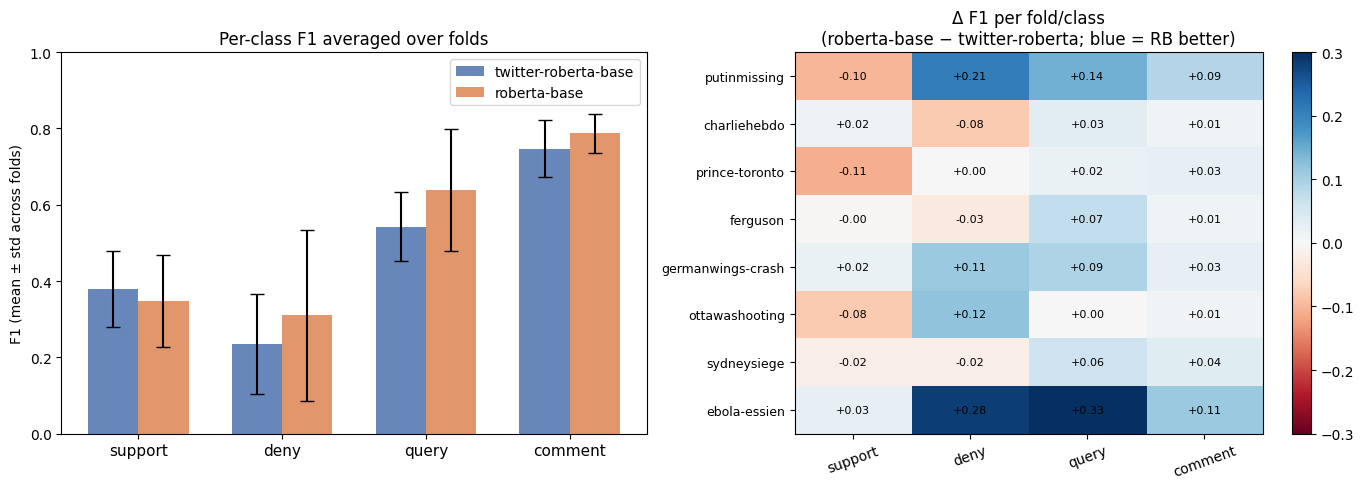

In [ ]:
tw_pcf1 = np.array([tw[e]["per_class_f1_mean"] for e in events])  # (8, 4)
rb_pcf1 = np.array([rb[e]["per_class_f1_mean"] for e in events])
diff    = rb_pcf1 - tw_pcf1

x_cls = np.arange(4)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x_cls - W/2, tw_pcf1.mean(0), W, yerr=tw_pcf1.std(0), capsize=5,
            color=TW_COLOR, label="twitter-roberta-base", alpha=0.85)
axes[0].bar(x_cls + W/2, rb_pcf1.mean(0), W, yerr=rb_pcf1.std(0), capsize=5,
            color=RB_COLOR, label="roberta-base",         alpha=0.85)
axes[0].set_xticks(x_cls); axes[0].set_xticklabels(LABEL_NAMES, fontsize=11)
axes[0].set_ylabel("F1 (mean ± std across folds)"); axes[0].set_ylim(0, 1.0)
axes[0].set_title("Per-class F1 averaged over folds"); axes[0].legend()

im = axes[1].imshow(diff, vmin=-0.3, vmax=0.3, aspect="auto", cmap="RdBu")
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(LABEL_NAMES, rotation=20)
axes[1].set_yticks(range(len(events))); axes[1].set_yticklabels(events, fontsize=9)
axes[1].set_title("Δ F1 per fold/class\n(roberta-base − twitter-roberta; blue = RB better)")
for i in range(len(events)):
    for j in range(4):
        axes[1].text(j, i, f"{diff[i,j]:+.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig("outputs/comparison_per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 — Statistical significance

Runs statistical tests to check whether the score differences between the two models are large enough to be meaningful across the event folds.

In [ ]:
from scipy.stats import wilcoxon, ttest_rel

deltas = [rb[e]["macro_f1_mean"] - tw[e]["macro_f1_mean"] for e in events]

stat_wx, p_wx = wilcoxon(tw_macro, rb_macro)
stat_tt, p_tt = ttest_rel(tw_macro, rb_macro)

print("Statistical significance of macro-F1 difference (8 LOEO folds)")
print(f"  Mean delta (roberta-base minus twitter-roberta): {np.mean(deltas):+.4f}")
print(f"  Folds where roberta-base wins:    {sum(d > 0 for d in deltas)}/{len(deltas)}")
print(f"  Folds where twitter-roberta wins: {sum(d < 0 for d in deltas)}/{len(deltas)}")
print()
print(f"  Wilcoxon signed-rank:  W={stat_wx:.3f},  p={p_wx:.4f}")
print(f"  Paired t-test:         t={stat_tt:.3f},  p={p_tt:.4f}")
print()
sig = p_wx < 0.05
print(f"  Result is {'STATISTICALLY SIGNIFICANT' if sig else 'NOT statistically significant'}"
      f" (Wilcoxon p {'<' if sig else '>='} 0.05).")

Statistical significance of macro-F1 difference (8 LOEO folds)
  Mean delta (roberta-base minus twitter-roberta): +0.0447
  Folds where roberta-base wins:    6/8
  Folds where twitter-roberta wins: 2/8

  Wilcoxon signed-rank:  W=6.000,  p=0.1094
  Paired t-test:         t=-1.890,  p=0.1007

  Result is NOT statistically significant (Wilcoxon p >= 0.05).


## 10 — Confusion matrix gallery

Shows confusion matrices for each held-out event. These make it easier to see which labels the model confuses with each other.
Rows = true label, columns = predicted label.

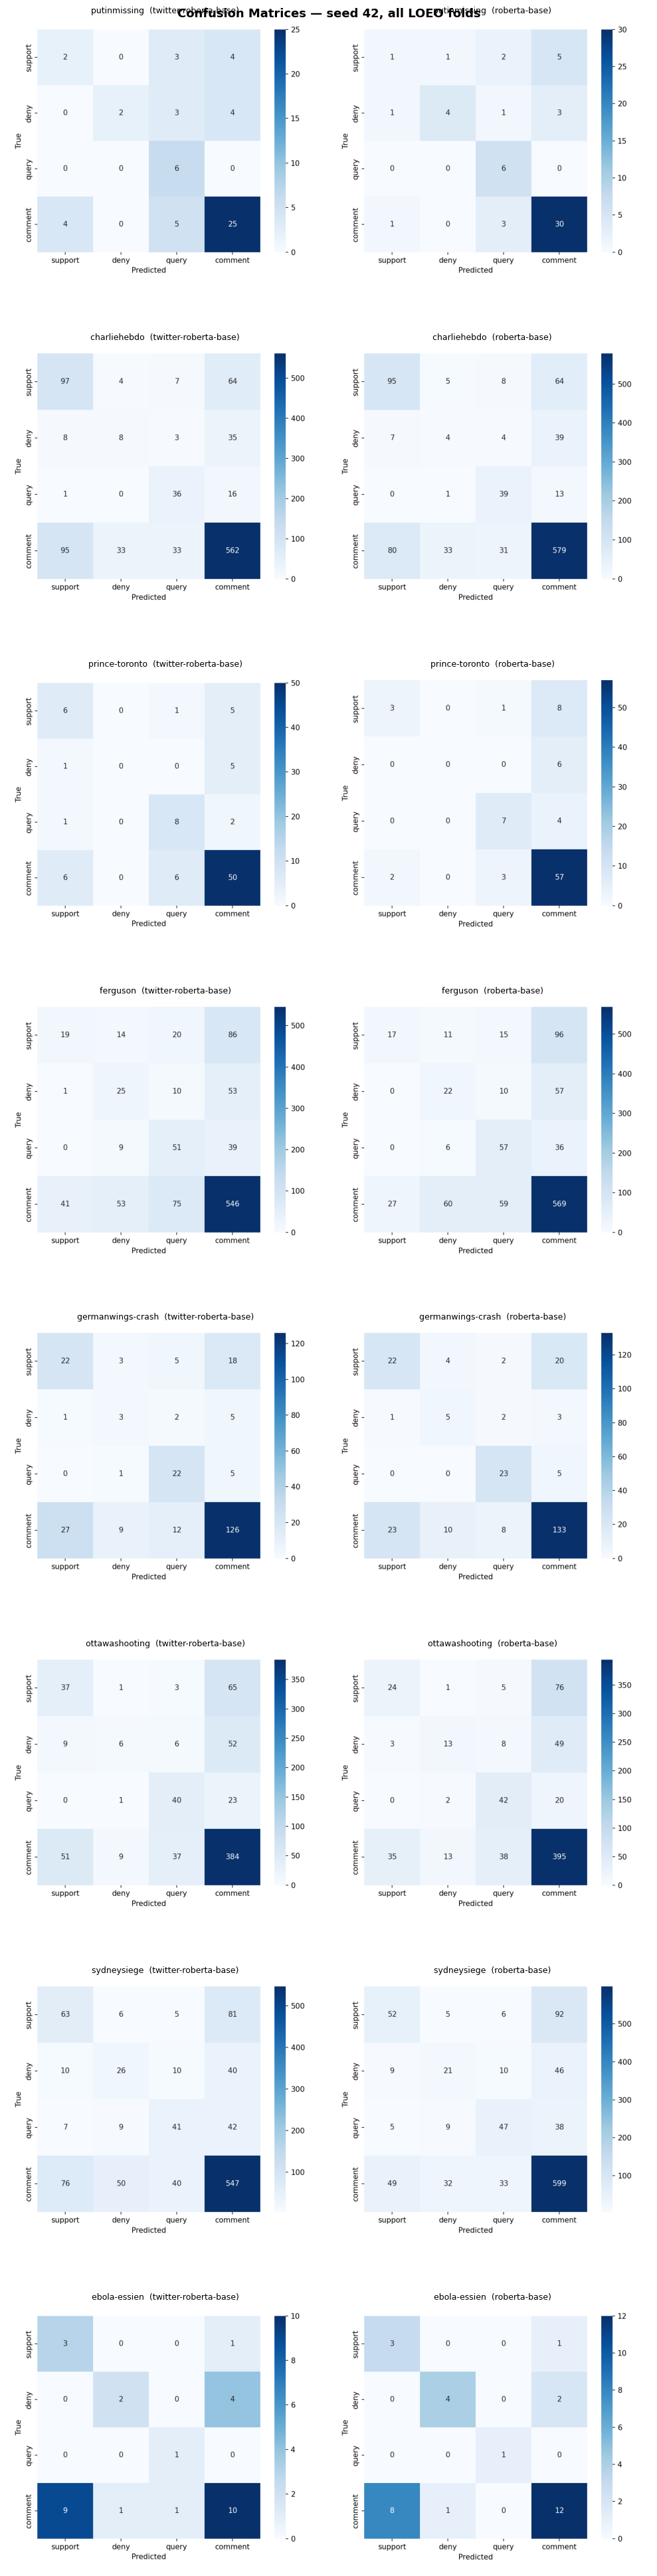

In [ ]:
from PIL import Image

SEED = 42

fig, axes = plt.subplots(len(events), 2, figsize=(10, 5 * len(events)))

for row, event in enumerate(events):
    for col, (prefix, label) in enumerate([
        ("outputs",              "twitter-roberta-base"),
        ("outputs_roberta_base", "roberta-base"),
    ]):
        img_path = Path(f"{prefix}/fold_{event}/seed_{SEED}/confusion_matrix.png")
        ax = axes[row][col]
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        else:
            ax.text(0.5, 0.5, "Not found", ha="center", va="center",
                    transform=ax.transAxes)
        ax.axis("off")
        ax.set_title(f"{event}  ({label})", fontsize=9)

plt.suptitle("Confusion Matrices — seed 42, all LOEO folds",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_gallery.png", dpi=120, bbox_inches="tight")
plt.show()

## 11 — Token attribution

Uses Integrated Gradients to see which input tokens had the most influence on the model’s predictions.

In [ ]:
import torch
import importlib
import config
from pathlib import Path
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from functools import partial

# Restore config defaults so model/dataset helpers use the right values
config.MODEL_NAME = "cardiffnlp/twitter-roberta-base"
config.OUTPUTS    = Path("outputs")

from model import StanceClassifier
from data import load_pheme_dataset, loeo_splits
from dataset import PhemeDataset, collate_fn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

ANALYSIS_EVENT = "charliehebdo"
SEED = 42

examples = load_pheme_dataset()
splits = {event: (train_ex, test_ex) for event, train_ex, test_ex in loeo_splits(examples)}
_, test_examples = splits[ANALYSIS_EVENT]
print(f"Test examples for '{ANALYSIS_EVENT}': {len(test_examples)}")

def load_model(model_name, ckpt_path):
    m = StanceClassifier(model_name, config.NUM_LABELS, pooling=config.POOLING)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    return m.eval().to(device)

TW_CKPT = f"outputs/fold_{ANALYSIS_EVENT}/seed_{SEED}/best_model.pt"
RB_CKPT = f"outputs_roberta_base/fold_{ANALYSIS_EVENT}/seed_{SEED}/best_model.pt"

tw_tok   = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base", add_prefix_space=True)
tw_model = load_model("cardiffnlp/twitter-roberta-base", TW_CKPT)
print("twitter-roberta-base loaded.")

rb_tok   = AutoTokenizer.from_pretrained("roberta-base", add_prefix_space=True)
rb_model = load_model("roberta-base", RB_CKPT)
print("roberta-base loaded.")

Device: cuda
Test examples for 'charliehebdo': 1002


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


twitter-roberta-base loaded.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


roberta-base loaded.


Computing Integrated Gradients for twitter-roberta-base...

Computing Integrated Gradients for roberta-base...



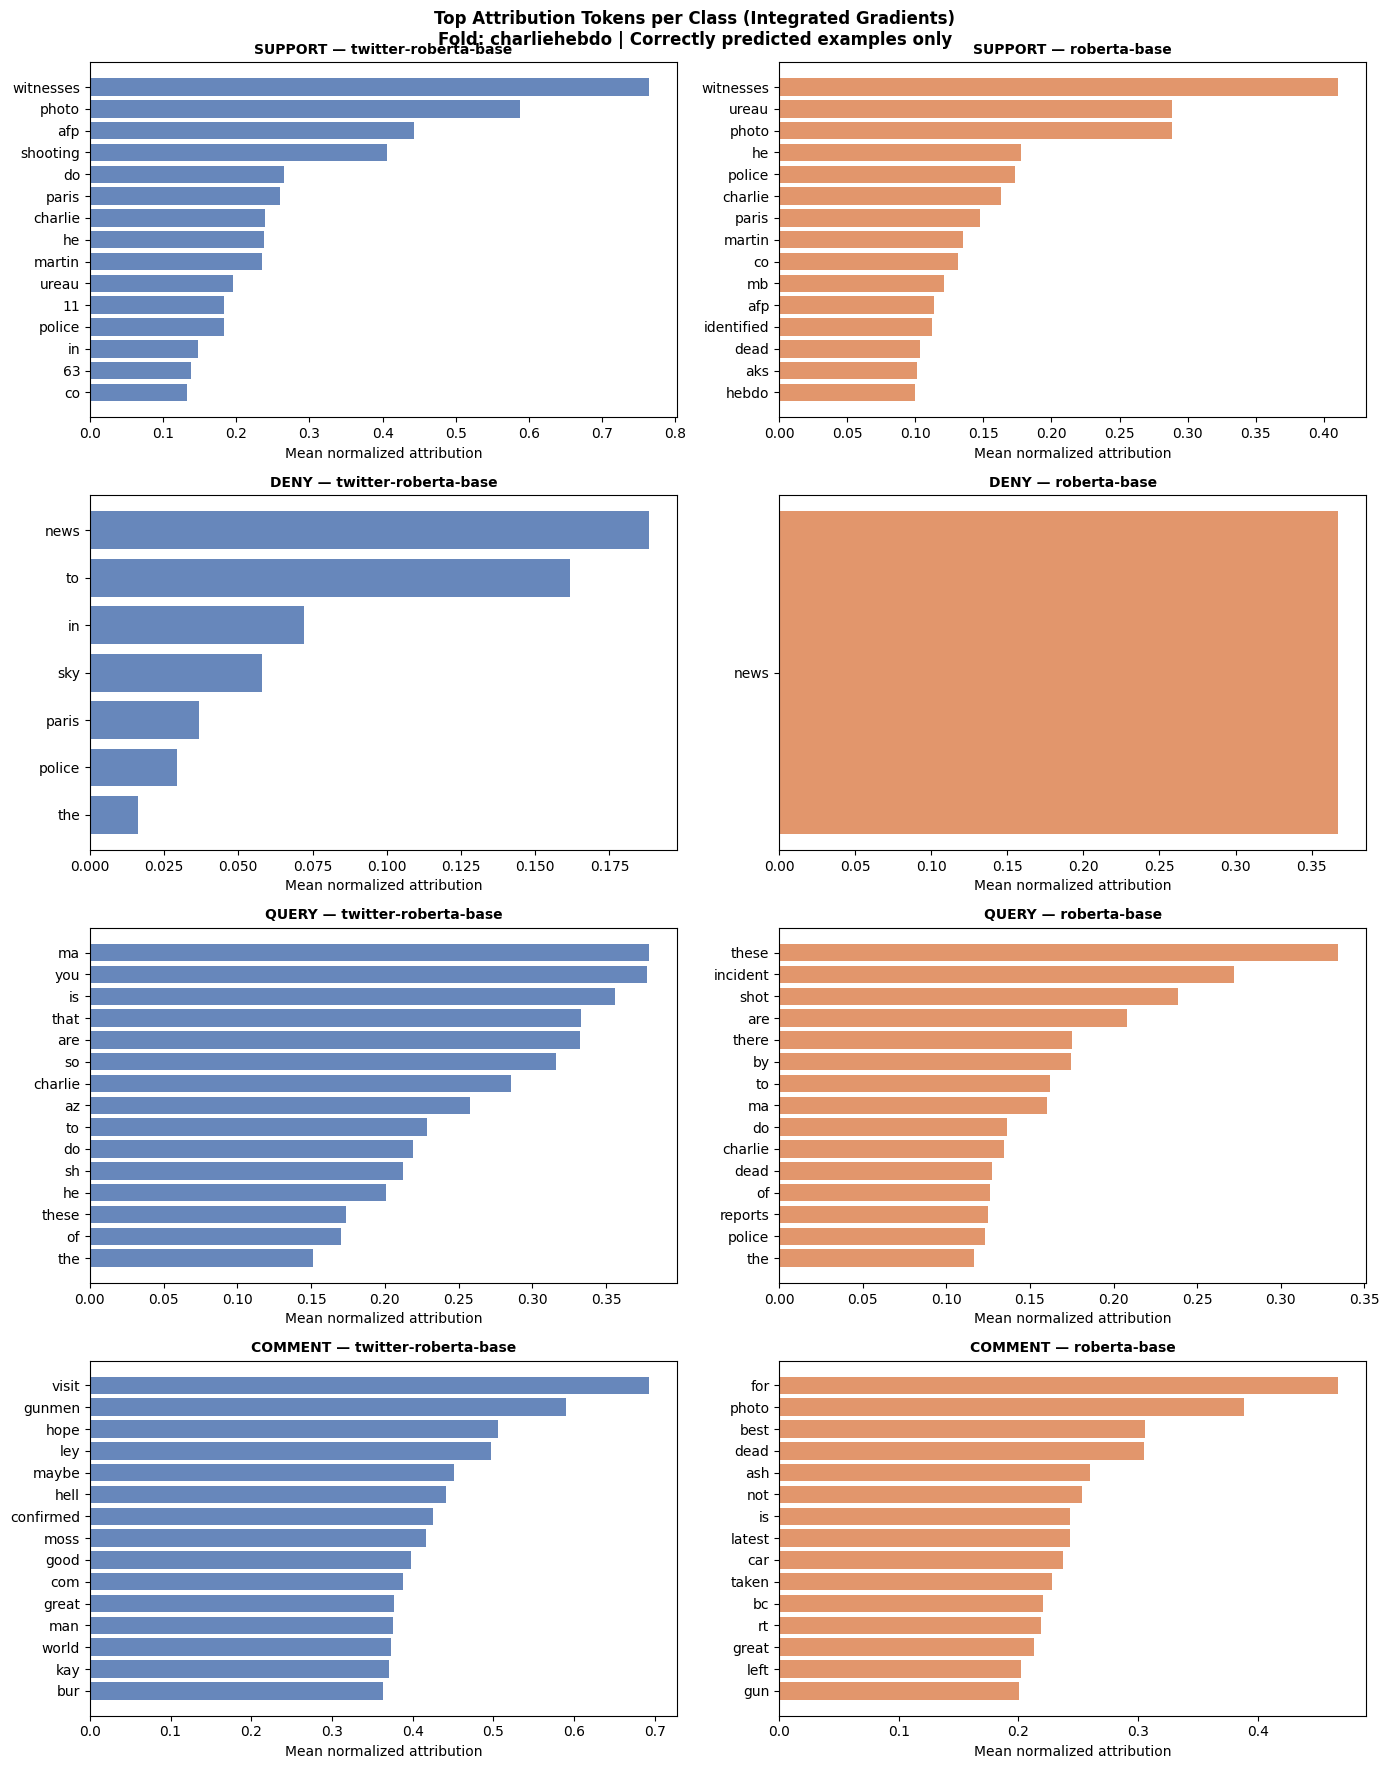

In [ ]:
from captum.attr import LayerIntegratedGradients
from collections import defaultdict
import re

def compute_ig_top_tokens(model, tokenizer, examples, device, n_steps=25, max_examples=150):
    SPECIAL = {tokenizer.bos_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id}
    loader  = DataLoader(
        PhemeDataset(examples[:max_examples], tokenizer, config.MAX_SEQ_LEN),
        batch_size=1,
        collate_fn=partial(collate_fn, pad_token_id=tokenizer.pad_token_id),
    )

    def forward_fn(input_ids, attention_mask):
        return model(input_ids=input_ids, attention_mask=attention_mask)["logits"]

    lig         = LayerIntegratedGradients(forward_fn, model.encoder.embeddings.word_embeddings)
    class_attrs = defaultdict(list)   # class_idx -> [(token_str, score)]

    for i, batch in enumerate(loader):
        if i % 25 == 0:
            print(f"  {i}/{min(max_examples, len(examples))}", end="\r")

        ids        = batch["input_ids"].to(device)
        mask       = batch["attention_mask"].to(device)
        true_label = batch["labels"].item()

        with torch.no_grad():
            pred = model(input_ids=ids, attention_mask=mask)["logits"].argmax(-1).item()
        if pred != true_label:
            continue  # only attribute correctly predicted examples

        baseline = torch.full_like(ids, tokenizer.pad_token_id)
        with torch.enable_grad():
            attrs = lig.attribute(
                inputs=ids, baselines=baseline,
                additional_forward_args=(mask,),
                target=pred, n_steps=n_steps,
            )  # (1, L, H)

        scores = attrs.sum(-1).squeeze(0)
        scores = (scores / (scores.abs().max() + 1e-8)).detach().cpu().numpy()

        for tok_id, score in zip(ids.squeeze(0).cpu().tolist(), scores):
            if tok_id in SPECIAL:
                continue
            tok_str = re.sub(r"[^a-z0-9'#@]", "",
                             tokenizer.decode([tok_id]).strip().lower())
            if len(tok_str) >= 2:
                class_attrs[pred].append((tok_str, float(score)))

    print()
    return class_attrs


def top_tokens(class_attrs, class_idx, topk=15, min_count=3):
    buckets = defaultdict(list)
    for tok, score in class_attrs.get(class_idx, []):
        if score > 0:
            buckets[tok].append(score)
    ranked = [(t, np.mean(s)) for t, s in buckets.items() if len(s) >= min_count]
    return sorted(ranked, key=lambda x: x[1], reverse=True)[:topk]


print("Computing Integrated Gradients for twitter-roberta-base...")
tw_attrs = compute_ig_top_tokens(tw_model, tw_tok, test_examples, device)

print("Computing Integrated Gradients for roberta-base...")
rb_attrs = compute_ig_top_tokens(rb_model, rb_tok, test_examples, device)

# ── plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for cls_idx, cls_name in enumerate(LABEL_NAMES):
    for col, (attrs, model_label, color) in enumerate([
        (tw_attrs, "twitter-roberta-base", TW_COLOR),
        (rb_attrs, "roberta-base",         RB_COLOR),
    ]):
        top = top_tokens(attrs, cls_idx)
        ax  = axes[cls_idx][col]
        ax.set_title(f"{cls_name.upper()} — {model_label}", fontsize=10, fontweight="bold")
        if not top:
            ax.text(0.5, 0.5, "Too few correct predictions", ha="center", va="center")
            continue
        tokens, scores = zip(*top)
        ax.barh(range(len(tokens)), scores, color=color, alpha=0.85)
        ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel("Mean normalized attribution")

plt.suptitle(
    "Top Attribution Tokens per Class (Integrated Gradients)\n"
    f"Fold: {ANALYSIS_EVENT} | Correctly predicted examples only",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig("outputs/token_attribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 12 — Embedding space

Uses t-SNE to visualize the model’s hidden representations. This gives a rough view of whether examples from different stance labels separate in the embedding space.

Extracting CLS embeddings...
Embedding shape: (1002, 768)
Fitting t-SNE (may take ~30 s each)...


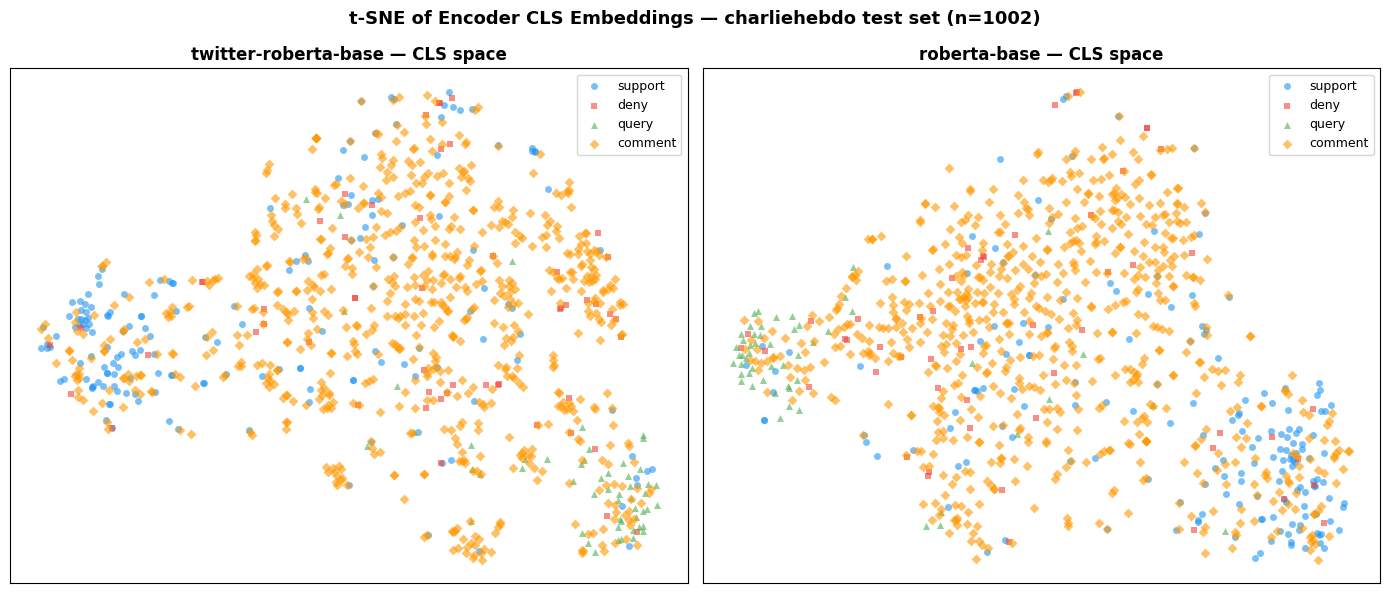

In [ ]:
from sklearn.manifold import TSNE

def extract_cls(model, tokenizer, examples, device, batch_size=32):
    loader = DataLoader(
        PhemeDataset(examples, tokenizer, config.MAX_SEQ_LEN),
        batch_size=batch_size, shuffle=False,
        collate_fn=partial(collate_fn, pad_token_id=tokenizer.pad_token_id),
    )
    embs, labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            out = model.encoder(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
            )
            embs.append(out.last_hidden_state[:, 0, :].cpu().float().numpy())
            labels.extend(batch["labels"].tolist())
    return np.vstack(embs), np.array(labels)

print("Extracting CLS embeddings...")
tw_embs, true_lbl = extract_cls(tw_model, tw_tok, test_examples, device)
rb_embs, _        = extract_cls(rb_model, rb_tok, test_examples, device)
print(f"Embedding shape: {tw_embs.shape}")

COLORS  = ["#2196F3", "#F44336", "#4CAF50", "#FF9800"]
MARKERS = ["o", "s", "^", "D"]

def plot_tsne(ax, embs, labels, title):
    proj = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(embs)
    for i, name in enumerate(LABEL_NAMES):
        mask = labels == i
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=COLORS[i], marker=MARKERS[i],
                   label=name, alpha=0.6, s=25, linewidths=0)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
print("Fitting t-SNE (may take ~30 s each)...")
plot_tsne(axes[0], tw_embs, true_lbl, "twitter-roberta-base — CLS space")
plot_tsne(axes[1], rb_embs, true_lbl, "roberta-base — CLS space")

plt.suptitle(
    f"t-SNE of Encoder CLS Embeddings — {ANALYSIS_EVENT} test set (n={len(test_examples)})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("outputs/tsne_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 13 — Error analysis

Finds examples where the two models disagree. Divergent cases — where one model
is right and the other wrong — reveal what each model uniquely captures about stance.

In [ ]:
def run_inference(model, tokenizer, examples, device):
    loader = DataLoader(
        PhemeDataset(examples, tokenizer, config.MAX_SEQ_LEN),
        batch_size=32, shuffle=False,
        collate_fn=partial(collate_fn, pad_token_id=tokenizer.pad_token_id),
    )
    preds = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            out = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
            )
            preds.extend(out["logits"].argmax(-1).cpu().tolist())
    return preds

print("Running inference on both models...")
tw_preds = run_inference(tw_model, tw_tok, test_examples, device)
rb_preds = run_inference(rb_model, rb_tok, test_examples, device)
true     = [ex["label"] for ex in test_examples]

tw_only, rb_only, both_wrong, both_right = [], [], [], []
for ex, t, tw_p, rb_p in zip(test_examples, true, tw_preds, rb_preds):
    entry = {
        "text":    ex["text"][:280],
        "true":    LABEL_NAMES[t],
        "tw_pred": LABEL_NAMES[tw_p],
        "rb_pred": LABEL_NAMES[rb_p],
    }
    if   tw_p == t and rb_p != t: tw_only.append(entry)
    elif rb_p == t and tw_p != t: rb_only.append(entry)
    elif tw_p != t and rb_p != t: both_wrong.append(entry)
    else:                          both_right.append(entry)

n = len(true)
print(f"Both correct:          {len(both_right):>4}  ({100*len(both_right)/n:.1f}%)")
print(f"twitter-roberta only:  {len(tw_only):>4}  ({100*len(tw_only)/n:.1f}%)")
print(f"roberta-base only:     {len(rb_only):>4}  ({100*len(rb_only)/n:.1f}%)")
print(f"Both wrong:            {len(both_wrong):>4}  ({100*len(both_wrong)/n:.1f}%)")


def show_examples(title, entries, n=5):
    print(f"\n{'='*65}\n{title}  (showing {min(n, len(entries))} of {len(entries)})\n{'='*65}")
    for e in entries[:n]:
        print(f"  true={e['true']:<10}  tw={e['tw_pred']:<10}  rb={e['rb_pred']}")
        print(f"  \"{e['text']}\"\n")

show_examples("twitter-roberta ONLY correct", tw_only)
show_examples("roberta-base ONLY correct",    rb_only)
show_examples("BOTH wrong",                  both_wrong)

from collections import Counter
print("\n--- Error breakdown by true label ---")
for title, entries in [
    ("TW only correct", tw_only),
    ("RB only correct", rb_only),
    ("Both wrong",      both_wrong),
]:
    print(f"  {title}: {dict(Counter(e['true'] for e in entries))}")

Running inference on both models...
Both correct:           657  (65.6%)
twitter-roberta only:    46  (4.6%)
roberta-base only:       60  (6.0%)
Both wrong:             239  (23.9%)

twitter-roberta ONLY correct  (showing 5 of 46)
  true=comment     tw=comment     rb=support
  "Inexpicable evil! “@MashableNews: 2 men wearing hoods &amp; black clothing shoot a wounded man #CharlieHebdo #ParisAttack http://t.co/dlPpRknrbi"

  true=comment     tw=comment     rb=deny
  "@juliamacfarlane @dangillmor classic misdirection. Probably seals or MI6."

  true=comment     tw=comment     rb=deny
  "@juliamacfarlane don't ask too many questions someone might accuse you of being a journalist"

  true=comment     tw=comment     rb=deny
  "@RT_com Means RPG."

  true=comment     tw=comment     rb=deny
  "@independent Islam never Support Terrorist"


roberta-base ONLY correct  (showing 5 of 60)
  true=comment     tw=support     rb=comment
  "MT @euronews France: 10 dead after shooting at HQ of satirical 

## 14 — Download all outputs

In [ ]:
!zip -r /content/analysis_outputs.zip \
    outputs/comparison_macro_f1_acc.png \
    outputs/comparison_per_class_f1.png \
    outputs/confusion_matrix_gallery.png \
    outputs/token_attribution_comparison.png \
    outputs/tsne_comparison.png

from google.colab import files
files.download("/content/analysis_outputs.zip")